# Visualizing Hugging Face text embeddings

Modern language models turn text into high-dimensional embedding vectors -- a perfect
match for HyperTools! In this tutorial we'll embed news headlines from a
[Hugging Face](https://huggingface.co) dataset using a small
[sentence-transformers](https://www.sbert.net) model, and then use HyperTools to
explore the embedding space.

This tutorial uses two extra libraries that are *not* installed with HyperTools.
You can install them by running:

```
%pip install sentence-transformers datasets
```


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from IPython.display import Image

import hypertools as hyp

## Embedding news headlines

We'll use a small sample (400 headlines) from the
[AG News](https://huggingface.co/datasets/fancyzhx/ag_news) dataset, which contains news
headlines from four categories: World, Sports, Business, and Sci/Tech.  To turn
each headline into a vector we'll use
[`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2),
a compact sentence-embedding model that maps each document onto a 384-dimensional
vector.

In [2]:
dataset = load_dataset('fancyzhx/ag_news', split='train[:400]')
label_names = dataset.features['label'].names
headlines = dataset['text']
categories = [label_names[i] for i in dataset['label']]

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode(headlines, show_progress_bar=False)
embeddings.shape

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(400, 384)

## Plotting the embedding space

Passing the category labels via the `hue` argument colors each headline by its
news category. HyperTools reduces the 384-dimensional embeddings to 3D
(using incremental PCA by default) before plotting.

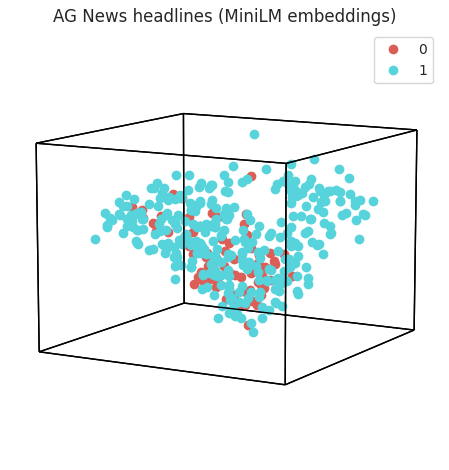

In [3]:
geo = hyp.plot(embeddings, 'o', hue=categories, legend=True,
               title='AG News headlines (MiniLM embeddings)')

Even in three dimensions, headlines from the same category tend to occupy the
same part of the embedding space.

## Soft clustering with Gaussian mixture models

What if we didn't know the category labels? We can discover structure directly
from the embeddings.  Setting `cluster='GaussianMixture'` fits a mixture model
and colors each observation by its *blend* of cluster memberships -- points
that sit between clusters get intermediate colors, revealing the soft category
boundaries.

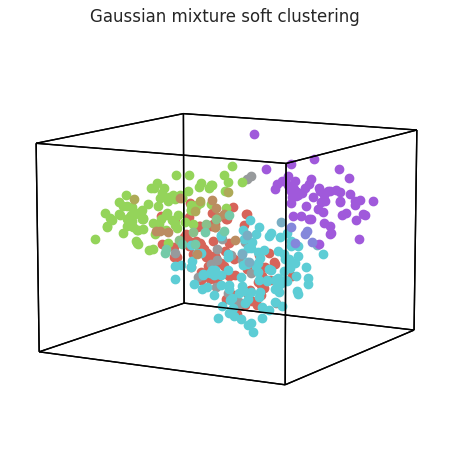

In [4]:
geo = hyp.plot(embeddings, 'o', cluster='GaussianMixture', n_clusters=4,
               title='Gaussian mixture soft clustering')

## Nonlinear embeddings with UMAP

PCA is linear; nonlinear methods like [UMAP](https://umap-learn.readthedocs.io)
can often do a better job of untangling text embeddings.  Just pass
`reduce='UMAP'`:

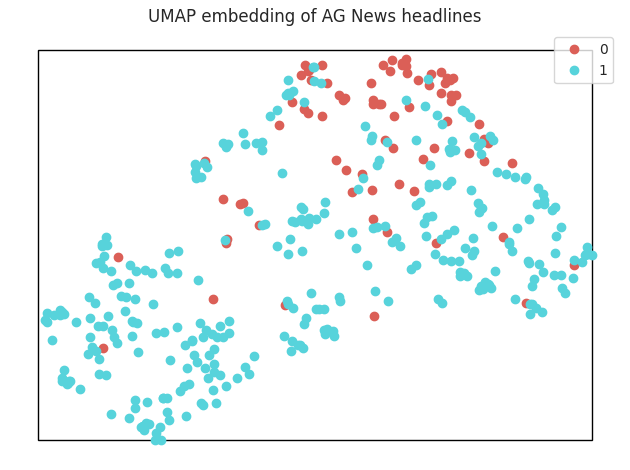

In [5]:
geo = hyp.plot(embeddings, 'o', reduce='UMAP', ndims=2,
               hue=categories, legend=True,
               title='UMAP embedding of AG News headlines')

## Animated 3D visualization

Finally, HyperTools can animate the plot -- `animate='spin'` rotates the 3D
scatter so we can inspect it from every angle, and `save_path` exports the
animation as a GIF (MP4 and animated SVG are also supported).

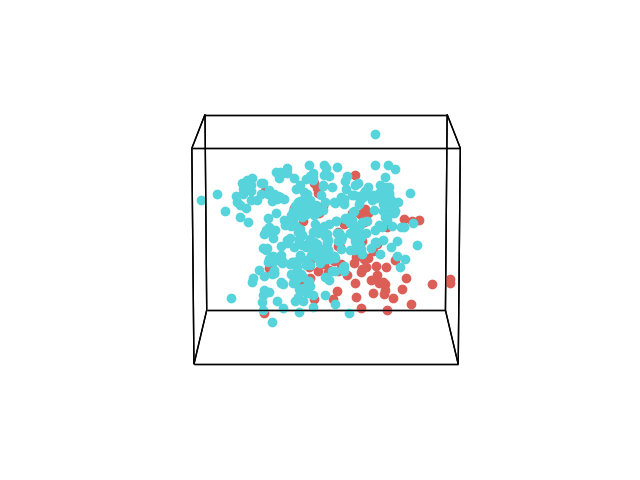

In [6]:
geo = hyp.plot(embeddings, 'o', hue=categories, animate='spin',
               duration=5, save_path='hf_embeddings_spin.gif', show=False)
Image('hf_embeddings_spin.gif')

## Next steps

Try swapping in a different Hugging Face dataset or embedding model, aligning
embeddings from *two* models with `hyp.align`, or exploring interactive 3D
plots with `backend='plotly'`.